In [1]:
# Kashish Bhardwaj

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
df = pd.read_csv("KaggleV2-May-2016.csv")
print(df.shape)
df.head()

(110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
df = df.rename(columns={"No-show": "NoShow"})
df["NoShow"] = df["NoShow"].map({"Yes": 1, "No": 0})
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])
df["LeadDays"] = (df["AppointmentDay"] - df["ScheduledDay"]).dt.days

df = df[df["LeadDays"] >= 0]

print("Cleaned! Shape:", df.shape)
print("No-show rate:", round(df["NoShow"].mean() * 100, 2), "%")

Cleaned! Shape: (71959, 15)
No-show rate: 28.52 %


C:\Users\lokis\AppData\Local\Temp\ipykernel_9968\2252472497.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_noshow.index, y=gender_noshow.values, palette="Blues")


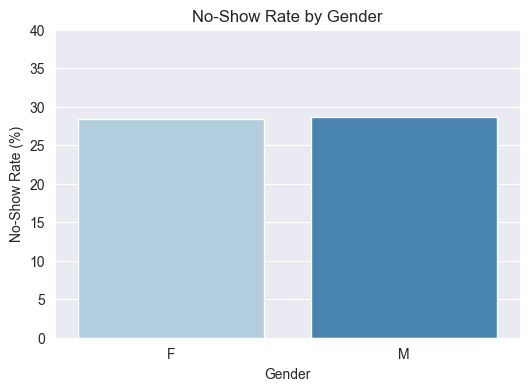

Chart 1 saved!


In [5]:
gender_noshow = df.groupby("Gender")["NoShow"].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=gender_noshow.index, y=gender_noshow.values, palette="Blues")
plt.title("No-Show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("No-Show Rate (%)")
plt.ylim(0, 40)
plt.savefig("chart1_gender_noshow.png")
plt.show()
print("Chart 1 saved!")

C:\Users\lokis\AppData\Local\Temp\ipykernel_9968\2097169628.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["No SMS", "SMS Sent"], y=sms_noshow.values, palette="Greens")


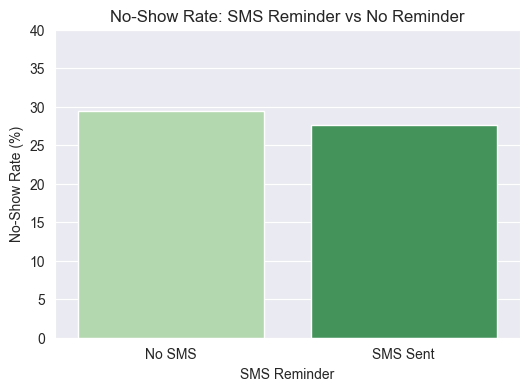

Chart 2 saved!


In [6]:
sms_noshow = df.groupby("SMS_received")["NoShow"].mean() * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=["No SMS", "SMS Sent"], y=sms_noshow.values, palette="Greens")
plt.title("No-Show Rate: SMS Reminder vs No Reminder")
plt.xlabel("SMS Reminder")
plt.ylabel("No-Show Rate (%)")
plt.ylim(0, 40)
plt.savefig("chart2_sms_noshow.png")
plt.show()
print("Chart 2 saved!")

C:\Users\lokis\AppData\Local\Temp\ipykernel_9968\2303710189.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_noshow.index, y=age_noshow.values, palette="Oranges")


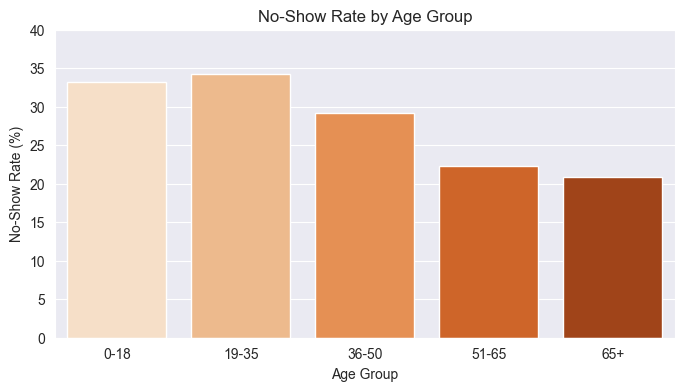

Chart 3 saved!


In [7]:
bins = [0, 18, 35, 50, 65, 100]
labels = ["0-18", "19-35", "36-50", "51-65", "65+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_noshow = df.groupby("AgeGroup", observed=True)["NoShow"].mean() * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=age_noshow.index, y=age_noshow.values, palette="Oranges")
plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")
plt.ylim(0, 40)
plt.savefig("chart3_age_noshow.png")
plt.show()
print("Chart 3 saved!")

In [8]:
print("   MEDICAL APPOINTMENT NO SHOW ANALYSIS:")
print(f"Total appointments analyzed: {len(df):,}")
print(f"Overall no show rate: {df['NoShow'].mean()*100:.1f}%")
print()
print("No show rate by age group:")
for group, rate in age_noshow.items():
    print(f"  {group}: {rate:.1f}%")
print()
print("No show rate by gender:")
for gender, rate in gender_noshow.items():
    print(f"  {gender}: {rate:.1f}%")
print()
sms_vals = sms_noshow.values
print(f"Without SMS reminder: {sms_vals[0]:.1f}%")
print(f"With SMS reminder: {sms_vals[1]:.1f}%")

   MEDICAL APPOINTMENT NO SHOW ANALYSIS:
Total appointments analyzed: 71,959
Overall no show rate: 28.5%

No show rate by age group:
  0-18: 33.2%
  19-35: 34.2%
  36-50: 29.1%
  51-65: 22.3%
  65+: 20.9%

No show rate by gender:
  F: 28.4%
  M: 28.7%

Without SMS reminder: 29.4%
With SMS reminder: 27.6%
